# Evaluación de modelos de forma programática

Durante el tema hemos visto cómo entrenar modelos, pero no cómo evaluarlos (simplemente los hemos comparado con un _train test split_).

Hemos ido viendo cómo crear nuevos modelos usando distintas estrategias, y comparábamos los resultados de estas nuevas estrategias con los anteriormente obtenidos. Si bien este proceso nos puede ayudar a hacernos una idea de qué estrategias _suelen_ ser mejores que otras, es cierto que es una simplificación (quizá demasiado fuerte) del proceso de evaluación de modelos.

El mayor inconveniente que tenemos a la hora de evaluar varios modelos es que estamos usando estrategias de generación de datos (aumento de datos) que generan datos diferentes en cada ejecución. Por ello, los resultados que obtenemos **no** son reproducibles y los resultados cambian de una ejecución la otra.

Durante este cuadernillo veremos cómo se deben evaluar los modelos (al menos, con un poco más de robustez), usando otras estrategias.

# Preparación del entorno de trabajo

Antes que nada, vamos a crear el mismo entorno que teníamos para el cuadernillo ```502```.

Intalamos las librerías necesarias (fastai).

Usaremos también un fragmento de código de [```vision_models_evaluation```](https://github.com/ruescog/vision_models_evaluation), una librería que desarrollé especialmente para este tipo de procesos.

In [ ]:
!pip install fastai -Uqqq
!pip install fastprogress==1.0.3 # 08/02/2026: esta librería se ha actualizado. Hasta que FASTAI se actualice, tenemos que usar la versión anterior

  Attempting uninstall: fastprogress
    Found existing installation: fastprogress 1.1.3
    Uninstalling fastprogress-1.1.3:
      Successfully uninstalled fastprogress-1.1.3


In [ ]:
import gc

from albumentations import *
from fastai.vision.all import *
from sklearn.model_selection import KFold, BaseCrossValidator

random_seed = 33

Recuperamos el _dataset_ del cuadernillo [```502```](https://cipfpd-my.sharepoint.com/:f:/g/personal/rescobedo_fpdrioja_es/EgmzwXhOQOBPsG7oktQ4uCMBNGi8gr6kEFHl1W0MiFPoRQ).

In [ ]:
%%capture
!unzip 502\ cat_dog_dataset.zip

In [ ]:
dataset_path = "dataset"
test_path = dataset_path + "/test"
train_path = dataset_path + "/train"

Creamos las transformaciones de aumento de datos.

In [ ]:
class TransformPipeline(ItemTransform):
  def __init__(self, train = True):
    if train:
      self.aug = Compose([
        VerticalFlip(p = 0.2),
        GaussNoise(p = 0.2),
        HorizontalFlip(p = 0.2),
        GridDistortion(p = 0.2)
      ])

  def encodes(self, x):
    if len(x) == 1:
      return x

    image, label = x
    res = self.aug(image = np.array(image)) # nuestro procesamiento es aplicar aumentos a la imagen
    return PILImage.create(res["image"]), label

Definimos la función para evaluar modelos (extraída del repositorio enlazado anteriormente).

In [ ]:
def evaluate(
    datablock_hparams: dict, # The hyperparameters used to get and load the data.
    dataloader_hparams: dict, # The hyperparameters used to define how the data is supplied to the learner.
    technique: BaseCrossValidator, # The technique used to split the data.
    learner_hparams: dict,  # The parameters used to build the learner (backbone, cbs...). Those hyperparams are used to build all the models.
    learning_hparams: dict, # The parameters used to train the learner (learning_rate, freeze_epochs).
    learning_mode: str = "finetune", # The learning mode: random or finetune.
    saving_hparams: dict = {"save_best": False}, # The model saving information {save_best: bool, metric: str}.
    verbose: bool = False # Whether the method shows logging messages
):
    # defines all the metrics used in the training and evaluation phases
    metrics = ["validation"]
    other_metrics = learner_hparams["metrics"] if "metrics" in learner_hparams else []
    all_metrics = list(map(lambda metric: metric if type(metric) == str else metric.__name__, metrics + other_metrics))
    results = dict([[metric, []] for metric in all_metrics])

    # gets all the data
    get_items_form = "get_items" if "get_items" in datablock_hparams else "get_x"
    get_items = [datablock_hparams[get_items_form], datablock_hparams["get_y"]]

    X = get_items[0](dataloader_hparams["source"])
    y = [get_items[1](x) for x in X]
    best_score = 0
    index = 1
    if verbose: print("Starting the training for a new model")
    for _, testing_indexes in technique.split(X, y):
        datablock_hparams["splitter"] = IndexSplitter(testing_indexes)
        if verbose: print(f"Training the fold {index}"); index += 1
        dls = DataBlock(**datablock_hparams).dataloaders(**dataloader_hparams)
        learner = vision_learner(dls, **learner_hparams).to_fp16()
        if learning_mode == "random":
            learner.fit_one_cycle(**learning_hparams)
        elif learning_mode == "finetune":
            learner.fine_tune(**learning_hparams)
        else:
            raise Exception(f"{learning_mode} is not a learning_mode. Use 'random' or 'finetune' instead.")

        # replaces the training dls and tests the model
        learner.dls = DataBlock(**datablock_hparams).dataloaders(**dataloader_hparams)
        log = ""
        for metric, metric_value in zip(results, learner.validate()):
            results[metric] += [metric_value]
            log += f"  {metric}: {metric_value}  /"

        if verbose: print(f"Test results for the model. {log[:-1]}")

        # saves the model
        if saving_hparams["save_best"]:
            score = results[saving_hparams["metric"]][-1]
            if score > best_score:
                if verbose: print(f"Saving best model because {saving_hparams['metric']} {round(score, 4)} >= {round(best_score, 4)}.")
                best_score = score
                learner.save(saving_hparams["model_name"])

        # wipes the memory of the gpu
        gc.collect()
        torch.cuda.empty_cache()

    return results

Definimos los hiperparámetros de nuestros objetos. Básicamente, una definición generalista de todo lo que vamos a usar: ```DataBlock```, ```DataLoader```, técnica de validación, ```Learner```, entrenamiento y método de entrenamiento.

Todo es dinámico.

In [ ]:
# hiperparámetros del datablock
datablock_hparams = {
    "blocks": (ImageBlock, CategoryBlock),
    "get_items": get_image_files,
    "get_y": parent_label,
    "item_tfms": [Resize(256), TransformPipeline(train = True)]
}

# hiperparámetros del dataloader
dataloader_hparams = {
    "source": train_path,
    "bs": 16
}

# la técnica de validacion
technique = KFold(n_splits = 5, shuffle = True, random_state = random_seed)

# hiperparámetros del learner
learner_hparams = {
    "arch": resnet18,
    "pretrained": True,
    "metrics": [accuracy],
    "cbs": [EarlyStoppingCallback(patience = 3)]
}

# hiperparámetros del entrenamiento
learning_hparams = {
    "epochs": 10,
    "base_lr": 0.001,
    "freeze_epochs": 2
}
learning_mode = "finetune"

Ejecutamos la función para evaluar el resultado. Como le hemos enviado la técnica de ```KFold```, entrenará varios ```Fold``` para nuestros modelos.

In [ ]:
result = evaluate(
    datablock_hparams,
    dataloader_hparams,
    technique,
    learner_hparams,
    learning_hparams,
    learning_mode,
    verbose = True
)

Starting the training for a new model
Training the fold 1
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 211MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,0.984107,0.447785,0.725000,00:03
1,0.748852,0.260015,0.900000,00:02


epoch,train_loss,valid_loss,accuracy,time
0,0.243621,0.258165,0.900000,00:03
1,0.269529,0.252602,0.925000,00:03
2,0.308187,0.192857,0.900000,00:02
3,0.304159,0.174410,0.900000,00:02
4,0.316875,0.213390,0.900000,00:03
5,0.296307,0.221785,0.900000,00:03
6,0.263189,0.286315,0.900000,00:02


No improvement since epoch 3: early stopping


...

Test results for the model.   validation: 0.3846028745174408  /  accuracy: 0.824999988079071  
Training the fold 5


epoch,train_loss,valid_loss,accuracy,time
0,1.228196,0.501738,0.700000,00:01
1,0.874876,0.173573,0.950000,00:01


epoch,train_loss,valid_loss,accuracy,time
0,0.450238,0.190221,0.950000,00:01
1,0.413554,0.159381,0.950000,00:01
2,0.403724,0.104619,0.950000,00:02
3,0.337586,0.111371,0.925000,00:01
4,0.383183,0.127445,0.950000,00:01
5,0.340330,0.110067,0.925000,00:01


No improvement since epoch 2: early stopping


Test results for the model.   validation: 0.15942725539207458  /  accuracy: 0.925000011920929  


In [ ]:
df = pd.DataFrame(result)
df

,validation,accuracy
0,0.432877,0.850
1,0.538916,0.825
2,0.733097,0.825
3,0.384603,0.825
4,0.159427,0.925


In [ ]:
import os

model_name = "RESNET18"

if os.path.exists("results.csv"):
  _df = pd.DataFrame([model_name] + list(df["accuracy"])).transpose()
  _df.columns = [str(col) for col in _df.columns]
  df = pd.read_csv("results.csv")
  df = pd.concat([df, _df])
else:
  df = pd.DataFrame([model_name] + list(df["accuracy"])).transpose()

df.to_csv("results.csv", index = False)

Voy a entrenar ahora un ```resnet34``` siguiendo la misma estrategia.

In [ ]:
# hiperparámetros del learner
learner_hparams = {
    "arch": resnet34,
    "pretrained": True,
    "metrics": [accuracy],
    "cbs": [EarlyStoppingCallback(patience = 3)]
}

In [ ]:
result = evaluate(
    datablock_hparams,
    dataloader_hparams,
    technique,
    learner_hparams,
    learning_hparams,
    learning_mode,
    verbose = True
)

Starting the training for a new model
Training the fold 1
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 207MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,1.089613,0.610829,0.725000,00:01
1,0.829565,0.315020,0.925000,00:01


epoch,train_loss,valid_loss,accuracy,time
0,0.318894,0.343545,0.875000,00:02
1,0.329566,0.269566,0.900000,00:02
2,0.278146,0.264510,0.875000,00:01
3,0.251918,0.417990,0.850000,00:01
4,0.245393,0.344218,0.850000,00:01
5,0.230359,0.296311,0.900000,00:01


No improvement since epoch 2: early stopping


...

Test results for the model.   validation: 0.34118276834487915  /  accuracy: 0.824999988079071  
Training the fold 5


epoch,train_loss,valid_loss,accuracy,time
0,1.038837,0.502451,0.750000,00:01
1,0.736392,0.354921,0.875000,00:02


epoch,train_loss,valid_loss,accuracy,time
0,0.287326,0.252222,0.900000,00:02
1,0.298583,0.196349,0.950000,00:01
2,0.291158,0.282733,0.900000,00:01
3,0.256272,0.398366,0.875000,00:01
4,0.242846,0.349411,0.875000,00:01


No improvement since epoch 1: early stopping


Test results for the model.   validation: 0.13262517750263214  /  accuracy: 0.949999988079071  


Me guardo los resultados en mi fichero de resultados.

In [ ]:
df = pd.DataFrame(result)

model_name = "RESNET34"

if os.path.exists("results.csv"):
  _df = pd.DataFrame([model_name] + list(df["accuracy"])).transpose()
  _df.columns = [str(col) for col in _df.columns]
  df = pd.read_csv("results.csv")
  df = pd.concat([df, _df])
else:
  df = pd.DataFrame([model_name] + list(df["accuracy"])).transpose()

df.to_csv("results.csv", index = False)

Podríamos repetir esto para muchos tipos de modelos diferentes.

# Evaluación estadística de los resultados

Ahora vamos a evaluar los datos de forma estadística. Nuestro objetivo es encontrar diferencias **significativas** entre los distintos hiperparámetros que hemos probado.

In [ ]:
!pip install StatisticalAnalysis -Uqqq

  Preparing metadata (setup.py) ... done


In [ ]:
from StatisticalAnalysis import statisticalComparison

Evalúo mi _csv_ con los resultados.

results.csv
['RESNET18' 'RESNET34']
Report
**********************************************************
Mean and std
**********************************************************
RESNET18: 0.850000 (0.038730)
RESNET34: 0.860000 (0.048990)
**********************************************************
Statistical tests
**********************************************************
----------------------------------------------------------
Checking parametric conditions 
----------------------------------------------------------
Checking independence 
Ok
Checking normality using Shapiro-Wilk's test for normality, alpha=0.05
W: 0.709783, p:0.001158
The null hypothesis (normality) is rejected
Checking heteroscedasticity using Levene's test, alpha=0.05
W: 0.102564, p:0.756979
The null hypothesis (heteroscedasticity) is accepted
Conditions for a parametric test are not fulfilled, applying a non-parametric test
----------------------------------------------------------
Working with 2 algorithms
----------

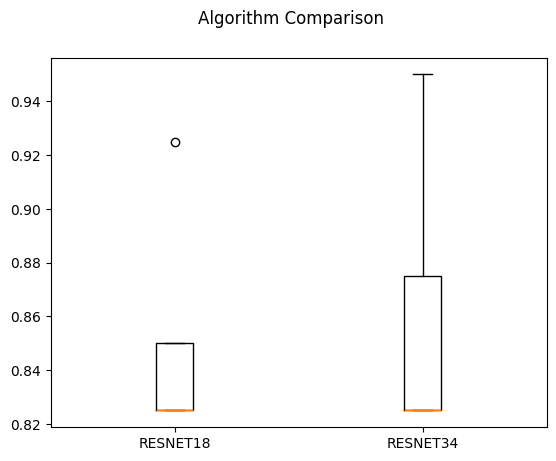

In [ ]:
statisticalComparison("results.csv")

Y, como resultado, podemos ver que **NO** podemos determinar matemáticamente que haya una diferencia estadística relevante entre estos dos modelos.